In [1]:
import pandas as pd
from src.data.clean_aggregated_dataset import clean
from src.utils.utils import find_project_root

root = find_project_root() / 'data' / 'aggregated' / 'dataset.csv'
df = clean(pd.read_csv(root))
df

,Assets (Rs.cr.),Company,EPS (Rs.) Pre-IPO,Ebitda (Rs.cr.),Issue Amount (Rs.cr.),Issue Price (Rs.),NII (x),Net Worth (Rs.cr.),Open Price on Listing (Rs.),P/E (x) Pre-IPO,...,Total (x),Total Borrowing (Rs.cr.),gmp_on_close,ipoEndDate,ipoStartDate,price_band_high,price_band_low,year,~IPO_Listing_Date,~id
0,61.59,Gujarat Kidney & Super Speciality Ltd.,1.85,8.63,250.80,114,4.73,30.56,120.00,61.62,...,3.42,4.03,NaN,2025-12-24,2025-12-22,114.0,108.0,2025,2025-12-30 00:00:00+00:00,2289
1,793.28,KSH International Ltd.,11.97,40.28,626.35,384,0.45,321.47,370.00,32.09,...,0.98,379.39,NaN,2025-12-18,2025-12-16,384.0,365.0,2025,2025-12-23 00:00:00+00:00,2454
2,4827.34,ICICI Prudential Asset Management Co.Ltd.,53.63,2210.10,10602.65,2165,21.00,3921.56,2600.00,40.37,...,28.19,NaN,NaN,2025-12-16,2025-12-12,2165.0,2061.0,2025,2025-12-19 00:00:00+00:00,2525
3,2320.93,Park Medi World Ltd.,5.55,217.14,920.00,162,15.51,1153.05,158.80,29.21,...,6.25,733.91,NaN,2025-12-12,2025-12-10,162.0,154.0,2025,2025-12-17 00:00:00+00:00,2297
4,1193.68,Nephrocare Health Services Ltd.,7.24,110.31,871.05,460,24.73,716.06,490.00,63.52,...,10.12,207.04,NaN,2025-12-12,2025-12-10,460.0,438.0,2025,2025-12-17 00:00:00+00:00,2548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,25448.81,Atlanta Ltd.,NaN,NaN,64.50,150,17.62,6243.47,175.55,NaN,...,10.57,NaN,NaN,2006-09-07,2006-09-01,150.0,130.0,2006,2006-09-25 00:00:00+00:00,5
716,19806.53,Deep Industries Ltd.,NaN,NaN,40.68,36,0.31,NaN,49.00,NaN,...,1.39,NaN,NaN,NaT,NaT,NaN,NaN,2006,2006-09-25 00:00:00+00:00,2
717,14.05,Voltamp Transformers Ltd.,NaN,NaN,168.49,345,22.58,NaN,370.00,NaN,...,17.37,NaN,NaN,2006-08-29,2006-08-24,345.0,295.0,2006,2006-09-20 00:00:00+00:00,1
718,121.77,Nitin Spinners Ltd.,NaN,NaN,40.00,21,27.97,42.36,30.00,NaN,...,20.23,NaN,NaN,2006-01-12,2006-01-06,21.0,18.0,2006,2006-02-02 00:00:00+00:00,2873


In [2]:
df.columns

Index(['Assets (Rs.cr.)', 'Company', 'EPS (Rs.) Pre-IPO', 'Ebitda (Rs.cr.)',
       'Issue Amount (Rs.cr.)', 'Issue Price (Rs.)', 'NII (x)',
       'Net Worth (Rs.cr.)', 'Open Price on Listing (Rs.)', 'P/E (x) Pre-IPO',
       'PAT Margin %', 'Price to Book Value', 'Profit After Tax (Rs.cr.)',
       'QIB (x)', 'ROCE', 'ROE', 'Reserves and Surplus (Rs.cr.)', 'Retail (x)',
       'Revenue (Rs.cr.)', 'RoNW', 'Total (x)', 'Total Borrowing (Rs.cr.)',
       'gmp_on_close', 'ipoEndDate', 'ipoStartDate', 'price_band_high',
       'price_band_low', 'year', '~IPO_Listing_Date', '~id'],
      dtype='str')

In [3]:
df['Open Price on Listing (Rs.)'].dtype, df['Issue Price (Rs.)'].dtype

(dtype('float64'), dtype('int64'))

In [7]:
col1, col2 = df['Open Price on Listing (Rs.)'], df['Issue Price (Rs.)']
df["listing_gain_pct"] = ((col1-col2)/col2)*100
print(df['listing_gain_pct'])

0       5.263158
1      -3.645833
2      20.092379
3      -1.975309
4       6.521739
         ...    
715    17.033333
716    36.111111
717     7.246377
718    42.857143
719    37.500000
Name: listing_gain_pct, Length: 720, dtype: float64


In [9]:
df['listing_gain_pct'] >= 5

0       True
1      False
2       True
3      False
4       True
       ...  
715     True
716     True
717     True
718     True
719     True
Name: listing_gain_pct, Length: 720, dtype: bool

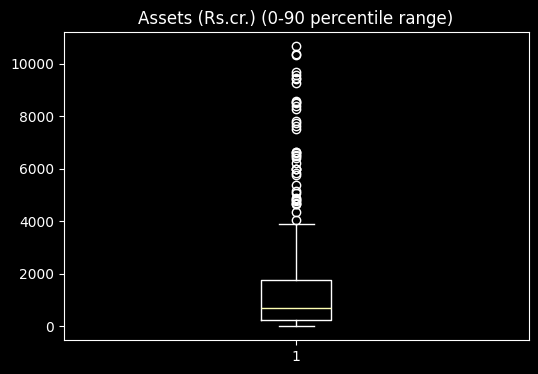

In [26]:
import matplotlib.pyplot as plt

def plot_histogram(df, column):
    plt.figure(figsize=(6, 4))
    plt.hist(df[column].dropna(), bins=100, edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

def plot_boxplot_range(df, column, lower=0, upper=99):
    import numpy as np
    import matplotlib.pyplot as plt

    data = df[column].dropna()
    l = np.percentile(data, lower)
    u = np.percentile(data, upper)

    filtered = data[(data >= l) & (data <= u)]

    plt.figure(figsize=(6, 4))
    plt.boxplot(filtered)
    plt.title(f"{column} ({lower}-{upper} percentile range)")
    plt.show()

plot_boxplot_range(df, 'Assets (Rs.cr.)', upper=90)
